# 📊 Guía de Visualización de Datos: Matplotlib y Seaborn

## 🎯 Introducción

La **visualización de datos** es una herramienta fundamental en Data Science y Machine Learning. Permite explorar patrones, detectar anomalías y comunicar resultados de forma efectiva. En este notebook aprenderás a usar las dos librerías más importantes de Python para visualización:

- **Matplotlib**: La librería base, ofrece control total sobre cada aspecto de un gráfico
- **Seaborn**: Construida sobre Matplotlib, proporciona estilos elegantes y sintaxis simplificada

## 🔧 Tipos de visualizaciones que veremos:

### **📥 1. Configuración y Carga de Datos**
- Importar librerías necesarias
- Cargar múltiples datasets
- Preparación del entorno

### **📊 2. Visualizaciones con Matplotlib**
- **Gráficos de barras**: Distribuciones categóricas
- **Histogramas**: Distribuciones de frecuencias
- **Gráficos de líneas**: Series temporales
- **Scatter plots**: Relaciones entre variables
- **Box plots**: Distribuciones y outliers
- **Mapas de calor**: Matrices de correlación
- **Mapas geográficos**: Visualizaciones espaciales
- **Gráficos circulares**: Proporciones

### **🎨 3. Visualizaciones con Seaborn**
- Sintaxis mejorada y estilos elegantes
- `countplot()`, `histplot()`, `lineplot()`
- `scatterplot()`, `boxplot()`, `heatmap()`
- Comparación de sintaxis con Matplotlib

### **🖼️ 4. Gráficos Combinados (Subplots)**
- Crear cuadrículas de gráficos
- `plt.subplots()` para múltiples visualizaciones
- Organización efectiva de dashboards

---

## 📚 Datasets utilizados:

Trabajaremos con tres datasets variados:
1. **50 Startups**: Datos financieros de startups
2. **California Housing**: Precios de viviendas en California
3. **Mall Customers**: Comportamiento de clientes en centros comerciales
4. **CTA Ridership**: Embarques diarios en transporte público de Chicago

## ⚙️ Configuración Inicial

> **⚠️ IMPORTANTE:** Si ejecutas este notebook en **VS Code** (en lugar de Google Colab), descomenta las siguientes líneas para evitar errores SSL al cargar datos desde URLs HTTPS.

In [28]:
# Descomenta estas líneas si usas VS Code:
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

# 📥 1. Configuración y Carga de Datos

Cargaremos varios datasets para poder explorar diferentes tipos de visualizaciones.

In [29]:
import pandas as pd

# Cargar datasets desde el repositorio GitHub
print("📥 Cargando datasets...")

startups_df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/50_Startups.csv")
print(f"✅ 50 Startups: {startups_df.shape[0]} filas, {startups_df.shape[1]} columnas")

housing_df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/housing.csv")
print(f"✅ California Housing: {housing_df.shape[0]} filas, {housing_df.shape[1]} columnas")

mall_df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/Mall_Customers.csv")
print(f"✅ Mall Customers: {mall_df.shape[0]} filas, {mall_df.shape[1]} columnas")

print("\n🎉 Todos los datasets cargados correctamente")

📥 Cargando datasets...
✅ 50 Startups: 50 filas, 5 columnas
✅ California Housing: 20640 filas, 10 columnas
✅ Mall Customers: 200 filas, 5 columnas

🎉 Todos los datasets cargados correctamente


# 📊 2. Visualizaciones con Matplotlib

Matplotlib es la librería base de visualización en Python. Ofrece **control total** sobre cada aspecto de un gráfico, pero requiere más código que Seaborn.

In [30]:
# Importar librerías de visualización
import matplotlib.pyplot as plt
import numpy as np

print("✅ Matplotlib y NumPy importados correctamente")

✅ Matplotlib y NumPy importados correctamente


### Gráficos de Barras

Ideales para comparar valores entre diferentes categorías.

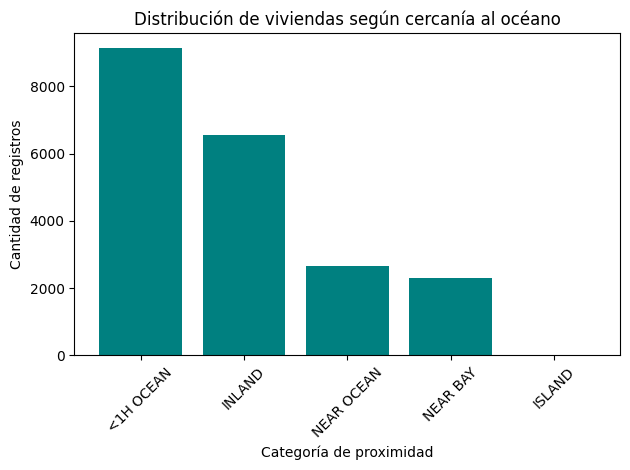

In [31]:
# Gráfico de barras básico
counts = housing_df['ocean_proximity'].value_counts()
plt.bar(counts.index, counts.values, color='teal')
plt.title('Distribución de viviendas según cercanía al océano')
plt.xlabel('Categoría de proximidad')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

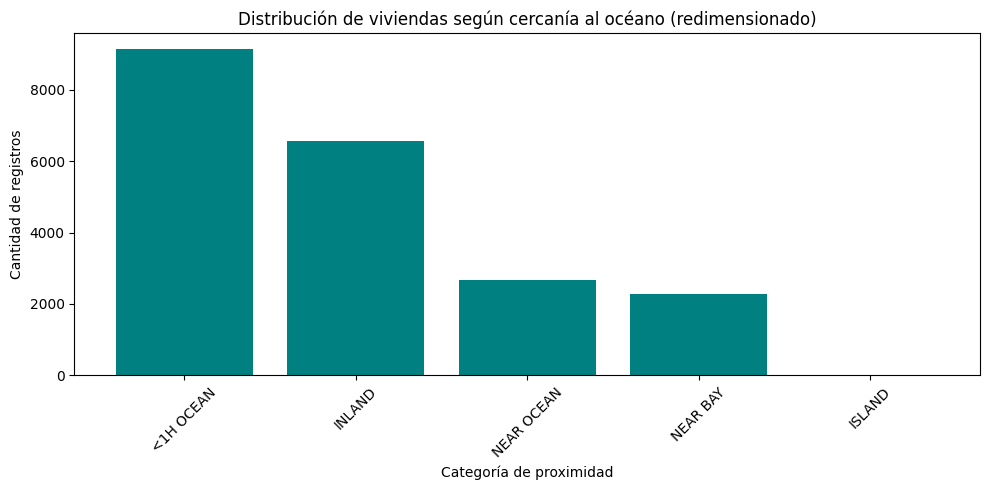

💡 Tip: Usa plt.figure(figsize=(width, height)) para ajustar el tamaño del gráfico


In [32]:
# Mismo gráfico pero con tamaño personalizado
plt.figure(figsize=(10, 5))  # 10 de ancho, 5 de alto
counts = housing_df['ocean_proximity'].value_counts()
plt.bar(counts.index, counts.values, color='teal')
plt.title('Distribución de viviendas según cercanía al océano (redimensionado)')
plt.xlabel('Categoría de proximidad')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("💡 Tip: Usa plt.figure(figsize=(width, height)) para ajustar el tamaño del gráfico")

### Histogramas

Muestran la distribución de frecuencias de una variable numérica.

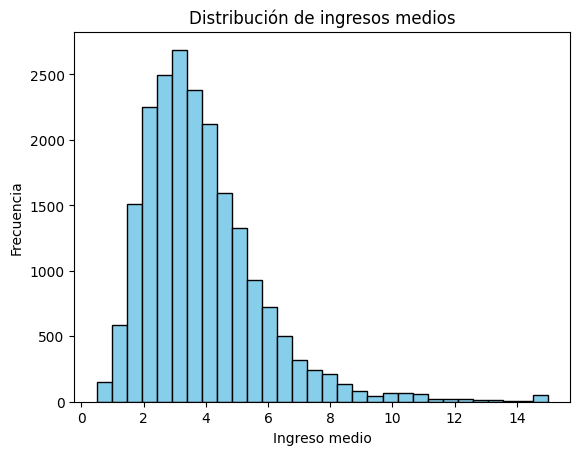

💡 El parámetro 'bins' controla el número de barras en el histograma


In [33]:
# Histograma básico con barras
plt.hist(housing_df['median_income'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de ingresos medios')
plt.xlabel('Ingreso medio')
plt.ylabel('Frecuencia')
plt.show()

print("💡 El parámetro 'bins' controla el número de barras en el histograma")

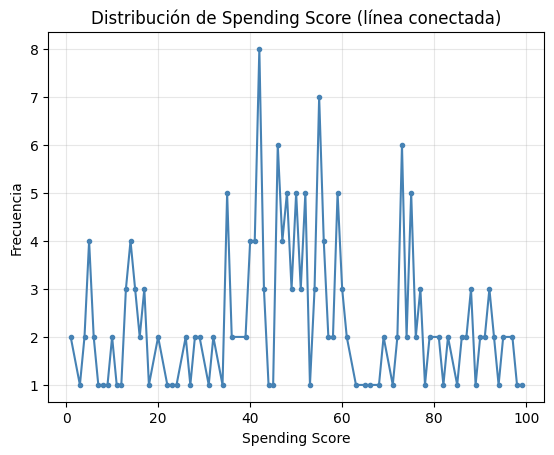

💡 value_counts().sort_index() organiza las frecuencias por valor de la variable


In [34]:
# Histograma con líneas suavizadas (distribución de frecuencias)
data = mall_df['Spending Score (1-100)'].dropna()

# Contar frecuencias directamente
counts = data.value_counts().sort_index()

# Dibujar línea conectando puntos
plt.plot(counts.index, counts.values, marker='.', linestyle='-', color='steelblue')
plt.title('Distribución de Spending Score (línea conectada)')
plt.xlabel('Spending Score')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

print("💡 value_counts().sort_index() organiza las frecuencias por valor de la variable")

### Gráficos Circulares (Pie Charts)

Muestran proporciones y porcentajes de diferentes categorías.

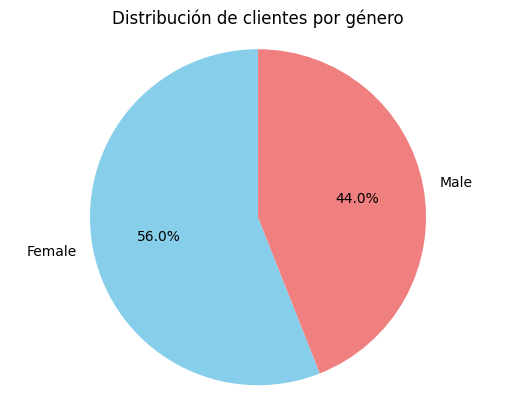

💡 autopct='%1.1f%%' muestra los porcentajes en el gráfico


In [35]:
# Gráfico circular (pie chart)
gender_counts = mall_df['Gender'].value_counts()
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribución de clientes por género')
plt.axis('equal')  # Mantiene el círculo perfectamente redondo
plt.show()

print("💡 autopct='%1.1f%%' muestra los porcentajes en el gráfico")

### Gráficos de Líneas (Series Temporales)

Ideales para mostrar evolución de datos a lo largo del tiempo.

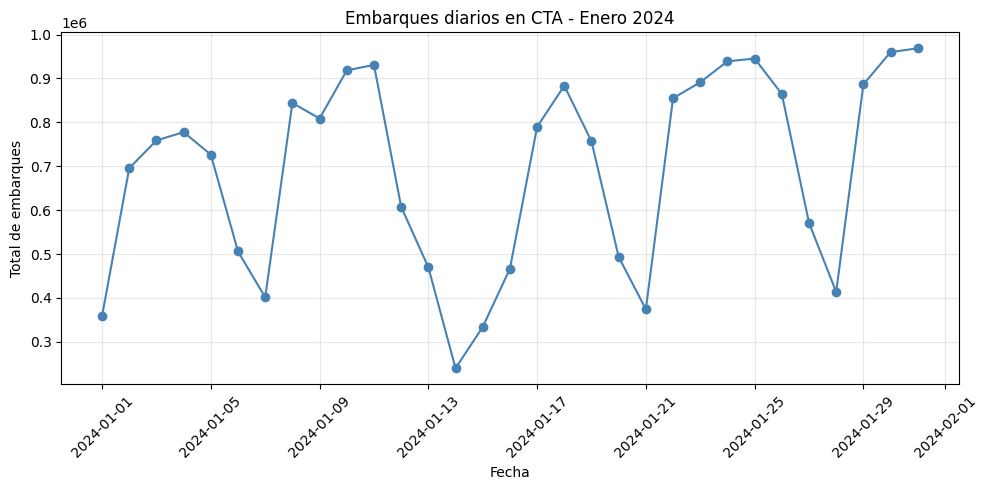

💡 Los gráficos de líneas son perfectos para visualizar tendencias temporales


In [36]:
# Cargar el dataset de embarques diarios en CTA (Chicago Transit Authority)
url = "https://data.cityofchicago.org/api/views/6iiy-9s97/rows.csv?accessType=DOWNLOAD"
cta_df = pd.read_csv(url)

# Convertir columna a datetime
cta_df['service_date'] = pd.to_datetime(cta_df['service_date'])

# Filtrar enero 2024
start_date = '2024-01-01'
end_date = '2024-01-31'
mask = (cta_df['service_date'] >= start_date) & (cta_df['service_date'] <= end_date)
cta_january_2024 = cta_df.loc[mask].sort_values('service_date')

# Graficar serie temporal
plt.figure(figsize=(10, 5))
plt.plot(cta_january_2024['service_date'], cta_january_2024['total_rides'], marker='o', linestyle='-', color='steelblue')
plt.title('Embarques diarios en CTA - Enero 2024')
plt.xlabel('Fecha')
plt.ylabel('Total de embarques')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Los gráficos de líneas son perfectos para visualizar tendencias temporales")

### Gráficos de Dispersión (Scatter Plots)

Muestran la relación entre dos variables numéricas.

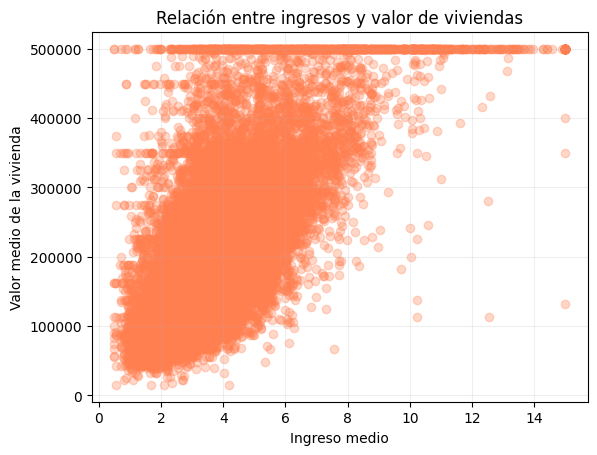

💡 El parámetro 'alpha' controla la transparencia (útil cuando hay muchos puntos)


In [37]:
# Gráfico de dispersión
plt.scatter(housing_df['median_income'], housing_df['median_house_value'], alpha=0.3, color='coral')
plt.title('Relación entre ingresos y valor de viviendas')
plt.xlabel('Ingreso medio')
plt.ylabel('Valor medio de la vivienda')
plt.grid(True, alpha=0.2)
plt.show()

print("💡 El parámetro 'alpha' controla la transparencia (útil cuando hay muchos puntos)")

### Diagramas de Caja (Box Plots)

Visualizan la distribución estadística de datos: mediana, cuartiles y outliers.

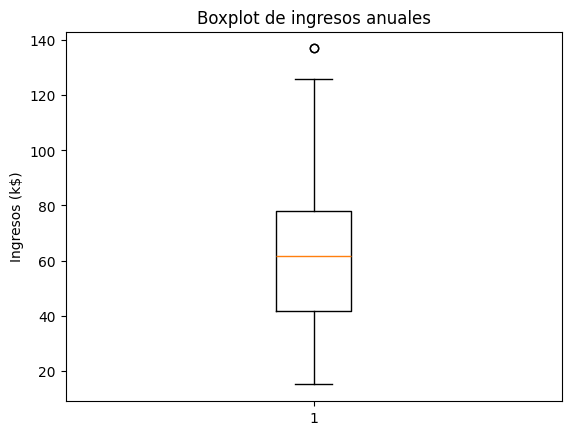

📊 La caja muestra Q1 (25%), mediana (50%) y Q3 (75%). Los puntos externos son outliers.


In [38]:
# Boxplot básico
plt.boxplot(mall_df['Annual Income (k$)'].dropna())
plt.title('Boxplot de ingresos anuales')
plt.ylabel('Ingresos (k$)')
plt.show()

print("📊 La caja muestra Q1 (25%), mediana (50%) y Q3 (75%). Los puntos externos son outliers.")

C:\Users\bzarco\AppData\Local\Temp\ipykernel_20408\555902826.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_category, labels=housing_df['ocean_proximity'].unique())


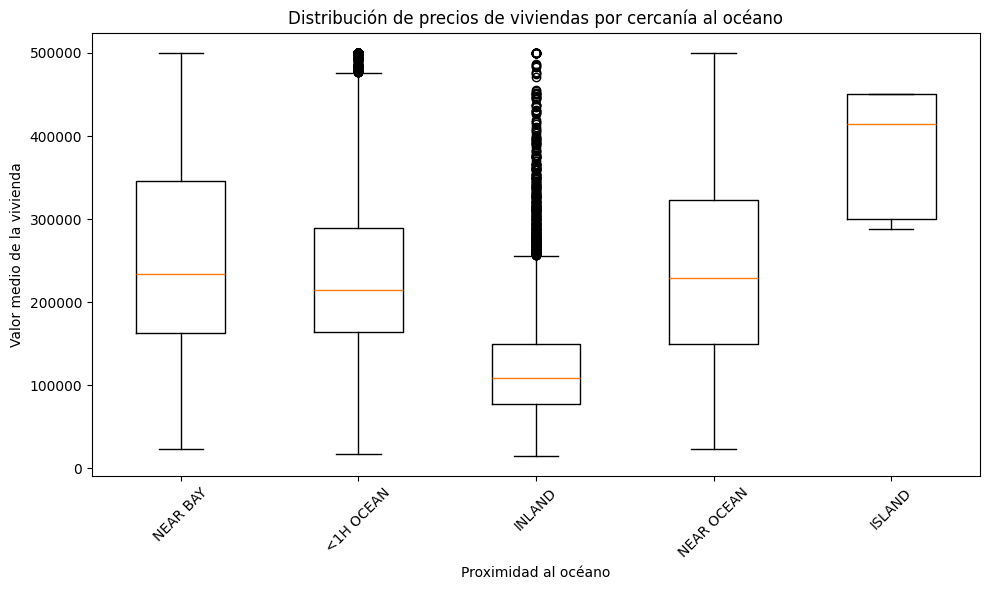

💡 Los boxplots permiten comparar distribuciones entre grupos diferentes


In [39]:
# Boxplot comparando múltiples categorías
data_by_category = [housing_df[housing_df['ocean_proximity'] == cat]['median_house_value'].dropna() 
                    for cat in housing_df['ocean_proximity'].unique()]

plt.figure(figsize=(10, 6))
plt.boxplot(data_by_category, labels=housing_df['ocean_proximity'].unique())
plt.title('Distribución de precios de viviendas por cercanía al océano')
plt.xlabel('Proximidad al océano')
plt.ylabel('Valor medio de la vivienda')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("💡 Los boxplots permiten comparar distribuciones entre grupos diferentes")

### Mapas de Calor (Heatmaps)

Visualizan matrices de datos usando colores. Ideales para matrices de correlación.

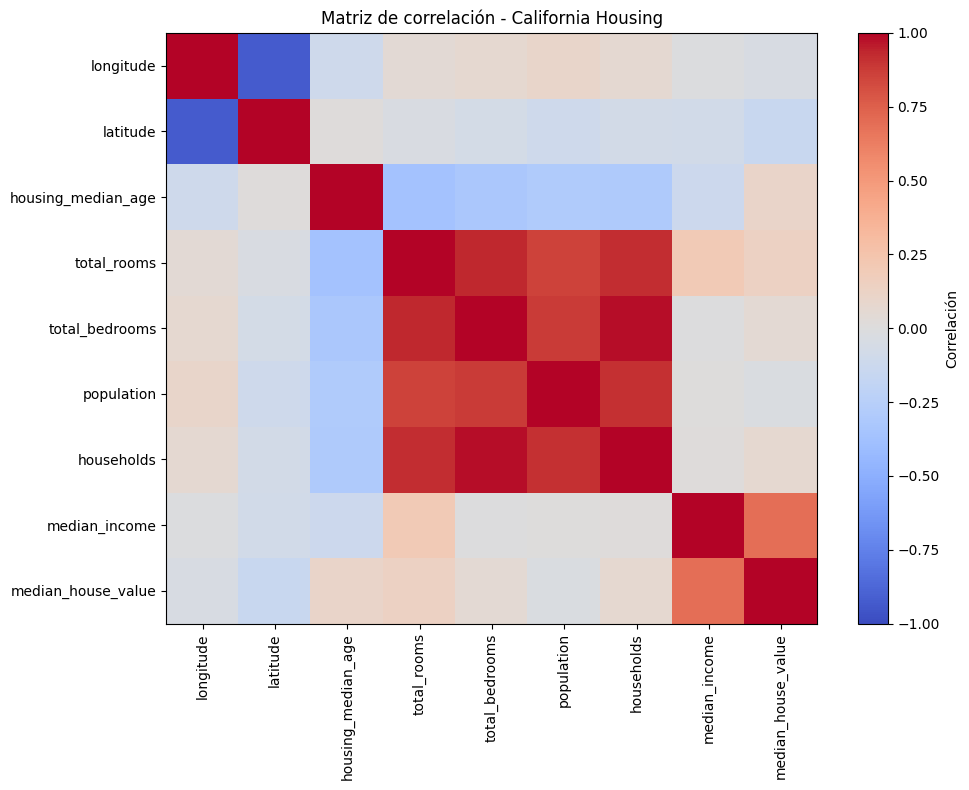

💡 Los colores rojos indican correlación positiva, azules correlación negativa


In [40]:
# Mapa de calor con matplotlib (matriz de correlación)
corr_matrix = housing_df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlación')
plt.title('Matriz de correlación - California Housing')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.tight_layout()
plt.show()

print("💡 Los colores rojos indican correlación positiva, azules correlación negativa")

### Mapas Geográficos

Visualización de datos con coordenadas geográficas (latitud y longitud).

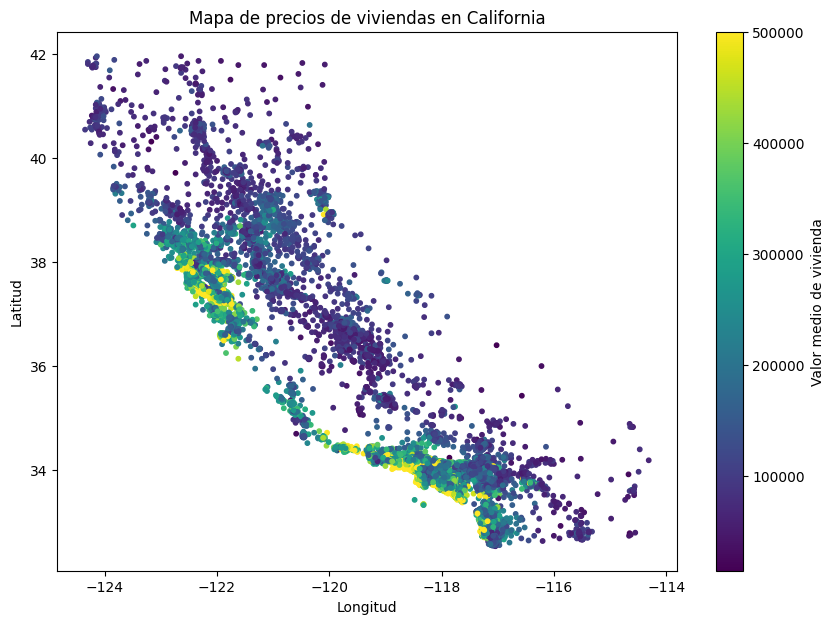

💡 Usamos scatter con color para representar una tercera variable en un mapa 2D


In [41]:
# Mapa geográfico con coordenadas (scatter plot con color)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(housing_df['longitude'], housing_df['latitude'], 
                     c=housing_df['median_house_value'], 
                     cmap='viridis', s=10)
plt.colorbar(scatter, label='Valor medio de vivienda')
plt.title('Mapa de precios de viviendas en California')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

print("💡 Usamos scatter con color para representar una tercera variable en un mapa 2D")

# 🎨 3. Visualizaciones con Seaborn

Seaborn es una librería de alto nivel construida sobre Matplotlib. **Ventajas**:
- Gráficos más estéticos por defecto
- Menos código para resultados similares
- Integración directa con DataFrames de pandas
- Paletas de colores profesionales predefinidas

In [42]:
import seaborn as sns

# Recargar los datasets (por si se reinició el kernel)
startups_df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/50_Startups.csv")
housing_df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/housing.csv")
mall_df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/Mall_Customers.csv")

print("✅ Seaborn importado y datasets recargados")

✅ Seaborn importado y datasets recargados


### Gráficos de Conteo (countplot)

Similar a gráficos de barras, pero cuenta automáticamente las categorías.

C:\Users\bzarco\AppData\Local\Temp\ipykernel_20408\2666485074.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=housing_df, x='ocean_proximity', palette='Set2')


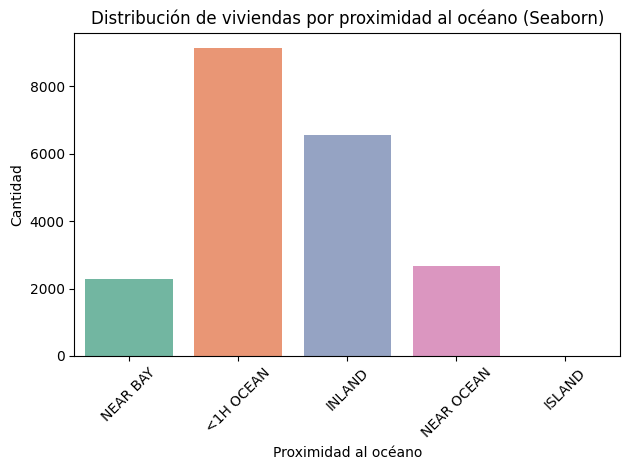

💡 Seaborn hace el conteo automáticamente, Matplotlib requiere value_counts() manual


In [43]:
# Countplot - cuenta automáticamente las categorías
sns.countplot(data=housing_df, x='ocean_proximity', palette='Set2')
plt.title('Distribución de viviendas por proximidad al océano (Seaborn)')
plt.xlabel('Proximidad al océano')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("💡 Seaborn hace el conteo automáticamente, Matplotlib requiere value_counts() manual")

### Histogramas (histplot)

Muestran distribuciones con más opciones que plt.hist().

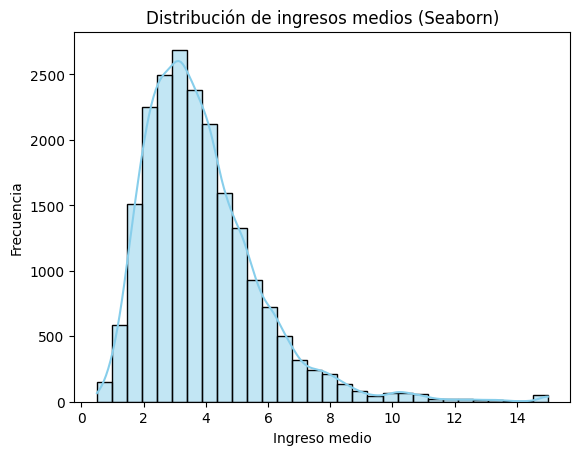

💡 Código más limpio que Matplotlib para el mismo resultado. Integra opciones como suavizado (kde), aplicar estilos...


In [44]:
# Histograma con Seaborn (sin KDE)
sns.histplot(housing_df['median_income'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de ingresos medios (Seaborn)')
plt.xlabel('Ingreso medio')
plt.ylabel('Frecuencia')
plt.show()

print("💡 Código más limpio que Matplotlib para el mismo resultado. Integra opciones como suavizado (kde), aplicar estilos...")

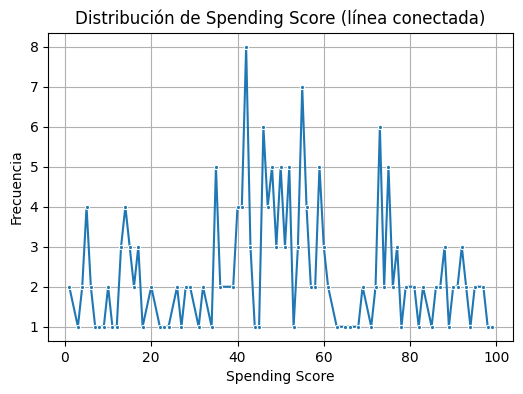

💡 Lineplot() de seaborn conecta los puntos de frecuencia limpiamente, aplicando estilos automáticos 
sin tener que configurarlos. Escala el eje x automáticamente.


In [45]:
# Histograma de puntos
data = mall_df['Spending Score (1-100)'].dropna()
counts = data.value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.lineplot(x=counts.index, y=counts.values, marker='.')
plt.title('Distribución de Spending Score (línea conectada)')
plt.xlabel('Spending Score')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

print("💡 Lineplot() de seaborn conecta los puntos de frecuencia limpiamente, aplicando estilos automáticos \nsin tener que configurarlos. Escala el eje x automáticamente.")

### Gráficos de Líneas (lineplot)

Seaborn agrega automáticamente intervalos de confianza en series temporales.

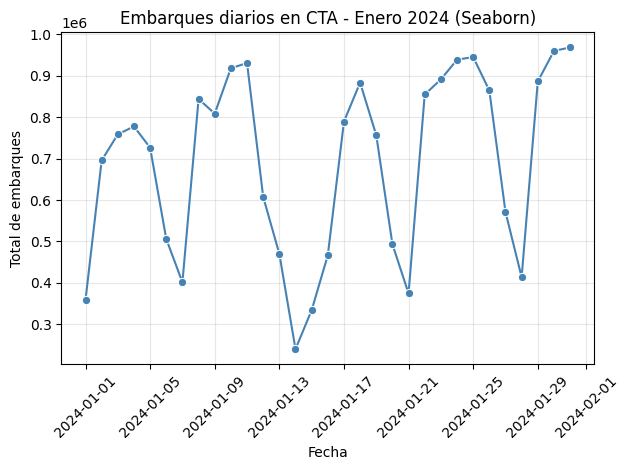

💡 Seaborn puede calcular automáticamente bandas de confianza para series temporales, detectando que son datos temporales 
y aplicando estilos automáticamente (rotado de fechas)


In [46]:
# Gráfico de líneas con Seaborn
sns.lineplot(data=cta_january_2024, x='service_date', y='total_rides', marker='o', color='steelblue')
plt.title('Embarques diarios en CTA - Enero 2024 (Seaborn)')
plt.xlabel('Fecha')
plt.ylabel('Total de embarques')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Seaborn puede calcular automáticamente bandas de confianza para series temporales, detectando que son datos temporales \ny aplicando estilos automáticamente (rotado de fechas)")

### Gráficos de Dispersión (scatterplot)

Más opciones de personalización que Matplotlib para scatter plots.

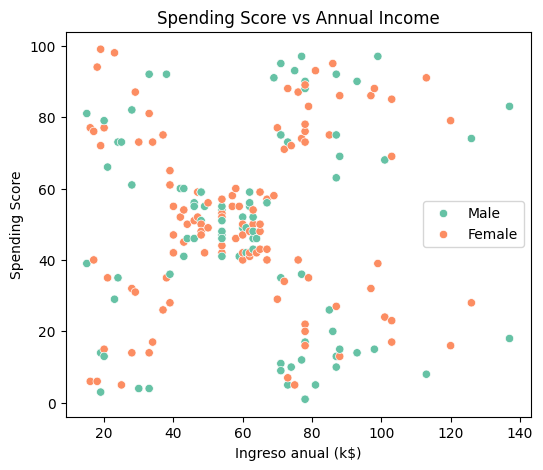

💡 Seaborn permite usar directamente el DataFrame con nombres de columna y agregar variables adicionales (hue para color, size para tamaño). 
No hace falta construir leyendas ni escalas manualmente.


In [47]:
# Diagrama de dispersión (scatterplot)
plt.figure(figsize=(6, 5))
sns.scatterplot(data=mall_df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', palette='Set2')
plt.title('Spending Score vs Annual Income')
plt.xlabel('Ingreso anual (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

print("💡 Seaborn permite usar directamente el DataFrame con nombres de columna y agregar variables adicionales (hue para color, size para tamaño). \nNo hace falta construir leyendas ni escalas manualmente.")

### Diagramas de Caja (boxplot)

Con Seaborn es más fácil crear boxplots por categorías.

C:\Users\bzarco\AppData\Local\Temp\ipykernel_20408\2332404901.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=housing_df, x='ocean_proximity', y='median_house_value', palette='Set2')


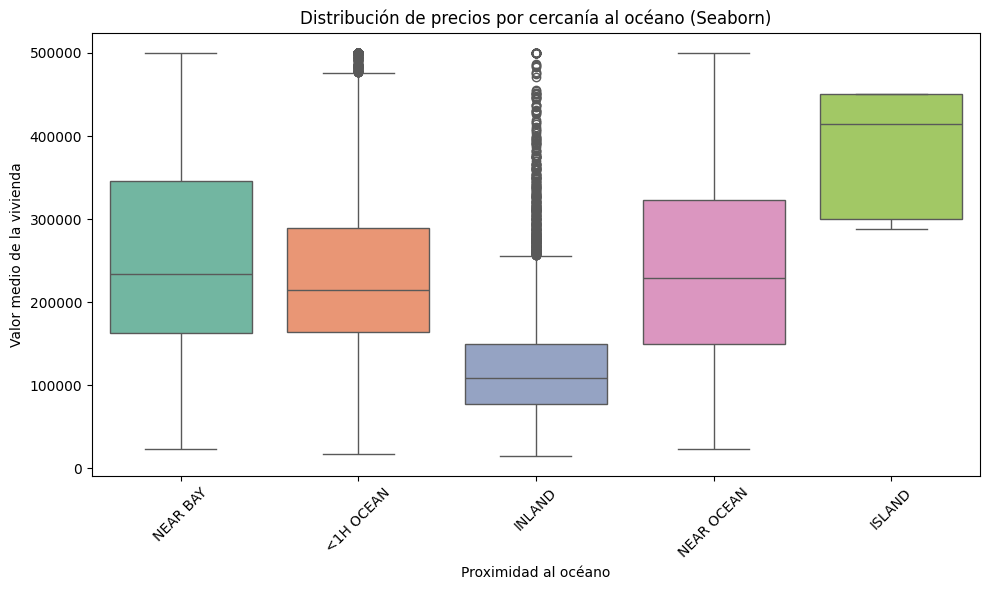

💡 Con Seaborn basta con especificar x e y, no necesitas preparar listas manualmente. Estilo automático y admite agrupación por categorías


In [48]:
# Boxplot con Seaborn (más fácil para comparar categorías)
plt.figure(figsize=(10, 6))
sns.boxplot(data=housing_df, x='ocean_proximity', y='median_house_value', palette='Set2')
plt.title('Distribución de precios por cercanía al océano (Seaborn)')
plt.xlabel('Proximidad al océano')
plt.ylabel('Valor medio de la vivienda')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("💡 Con Seaborn basta con especificar x e y, no necesitas preparar listas manualmente. Estilo automático y admite agrupación por categorías")

### Mapas de Calor (heatmap)

Seaborn crea heatmaps más legibles que Matplotlib con menos código.

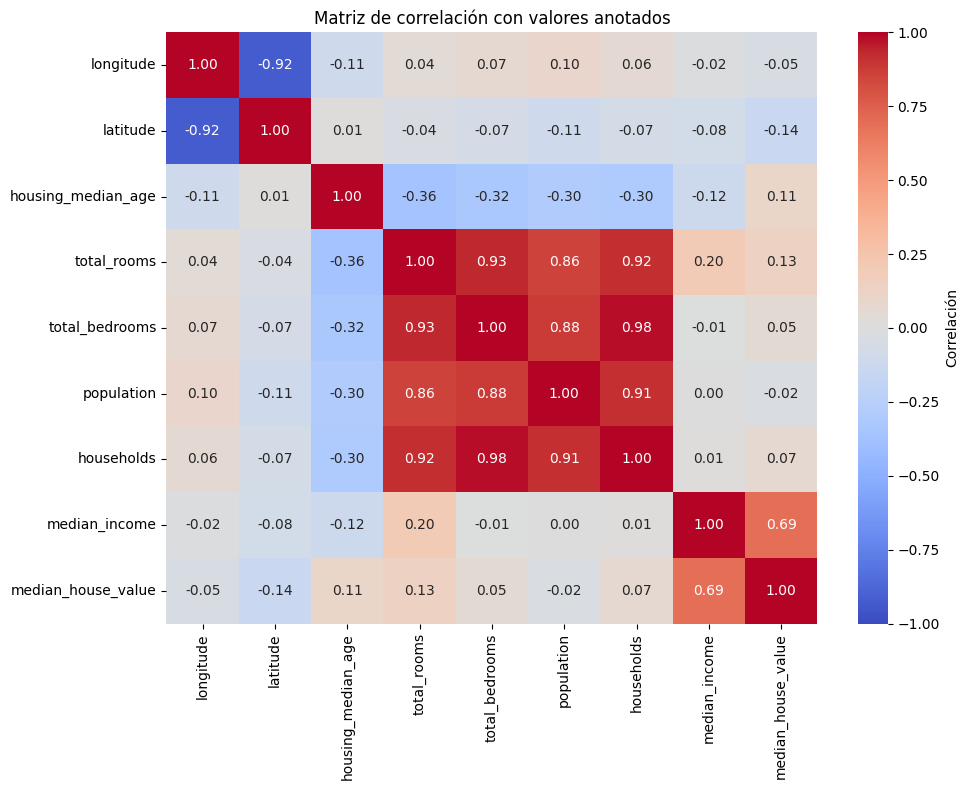

Seaborn permite mostrar lo mismo que matplotlib pero usando menos código (1 línea). 💡 annot=True muestra los valores numéricos dentro de cada celda


In [49]:
# Heatmap con valores anotados
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Correlación'})
plt.title('Matriz de correlación con valores anotados')
plt.tight_layout()
plt.show()

print("Seaborn permite mostrar lo mismo que matplotlib pero usando menos código (1 línea). 💡 annot=True muestra los valores numéricos dentro de cada celda")

# 🖼️ 4. Gráficos Combinados (Subplots)

Los **subplots** permiten mostrar múltiples gráficos en una misma figura. Útil para comparaciones directas.

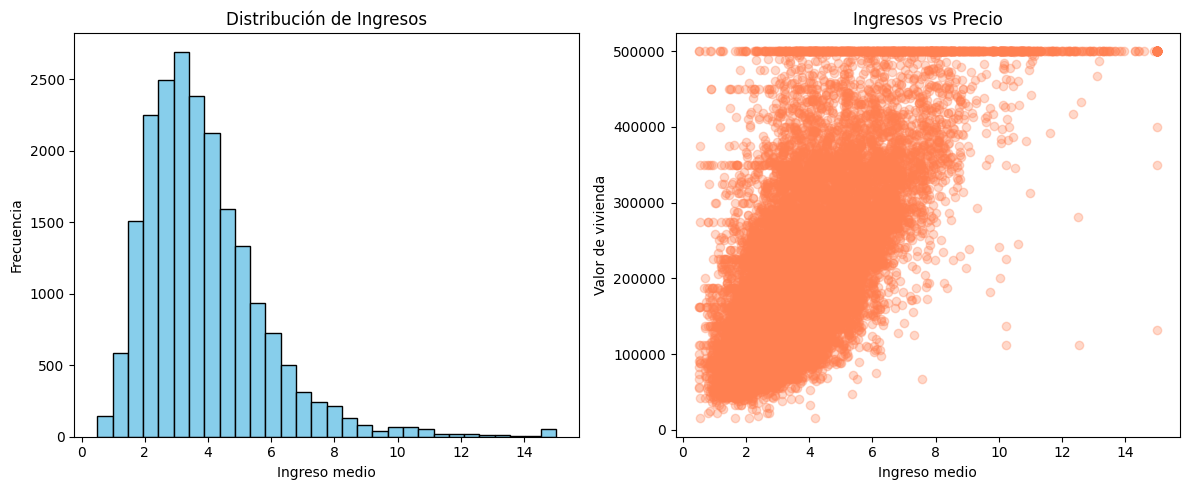

💡 plt.subplots(1, 2) crea 1 fila y 2 columnas de gráficos, se devuelven dos objetos el lienzo (fig) y un array de subgráficos (axes)


In [50]:
# Subplots 1x2 (una fila, dos columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1
axes[0].hist(housing_df['median_income'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de Ingresos')
axes[0].set_xlabel('Ingreso medio')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2
axes[1].scatter(housing_df['median_income'], housing_df['median_house_value'], alpha=0.3, color='coral')
axes[1].set_title('Ingresos vs Precio')
axes[1].set_xlabel('Ingreso medio')
axes[1].set_ylabel('Valor de vivienda')

plt.tight_layout()
plt.show()

print("💡 plt.subplots(1, 2) crea 1 fila y 2 columnas de gráficos, se devuelven dos objetos el lienzo (fig) y un array de subgráficos (axes)")

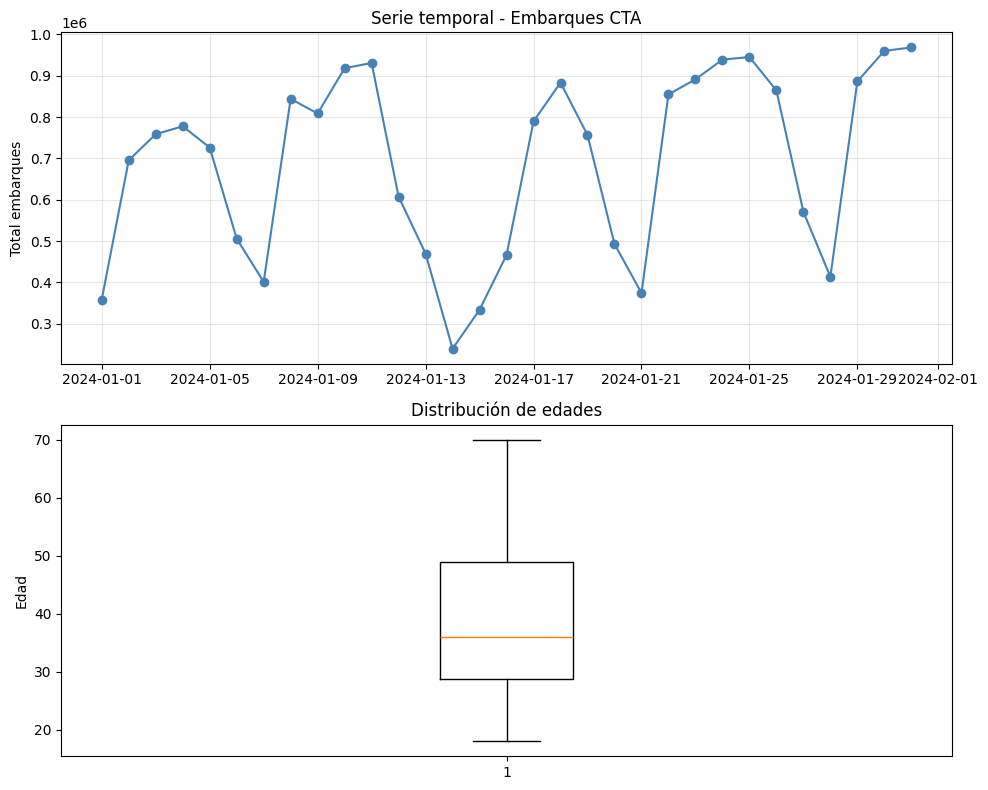

💡 plt.subplots(2, 1) crea 2 filas y 1 columna de gráficos


In [51]:
# Subplots 2x1 (dos filas, una columna)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Gráfico 1 (arriba)
axes[0].plot(cta_january_2024['service_date'], cta_january_2024['total_rides'], marker='o', color='steelblue')
axes[0].set_title('Serie temporal - Embarques CTA')
axes[0].set_ylabel('Total embarques')
axes[0].grid(True, alpha=0.3)

# Gráfico 2 (abajo)
axes[1].boxplot(mall_df['Age'].dropna())
axes[1].set_title('Distribución de edades')
axes[1].set_ylabel('Edad')

plt.tight_layout()
plt.show()

print("💡 plt.subplots(2, 1) crea 2 filas y 1 columna de gráficos")

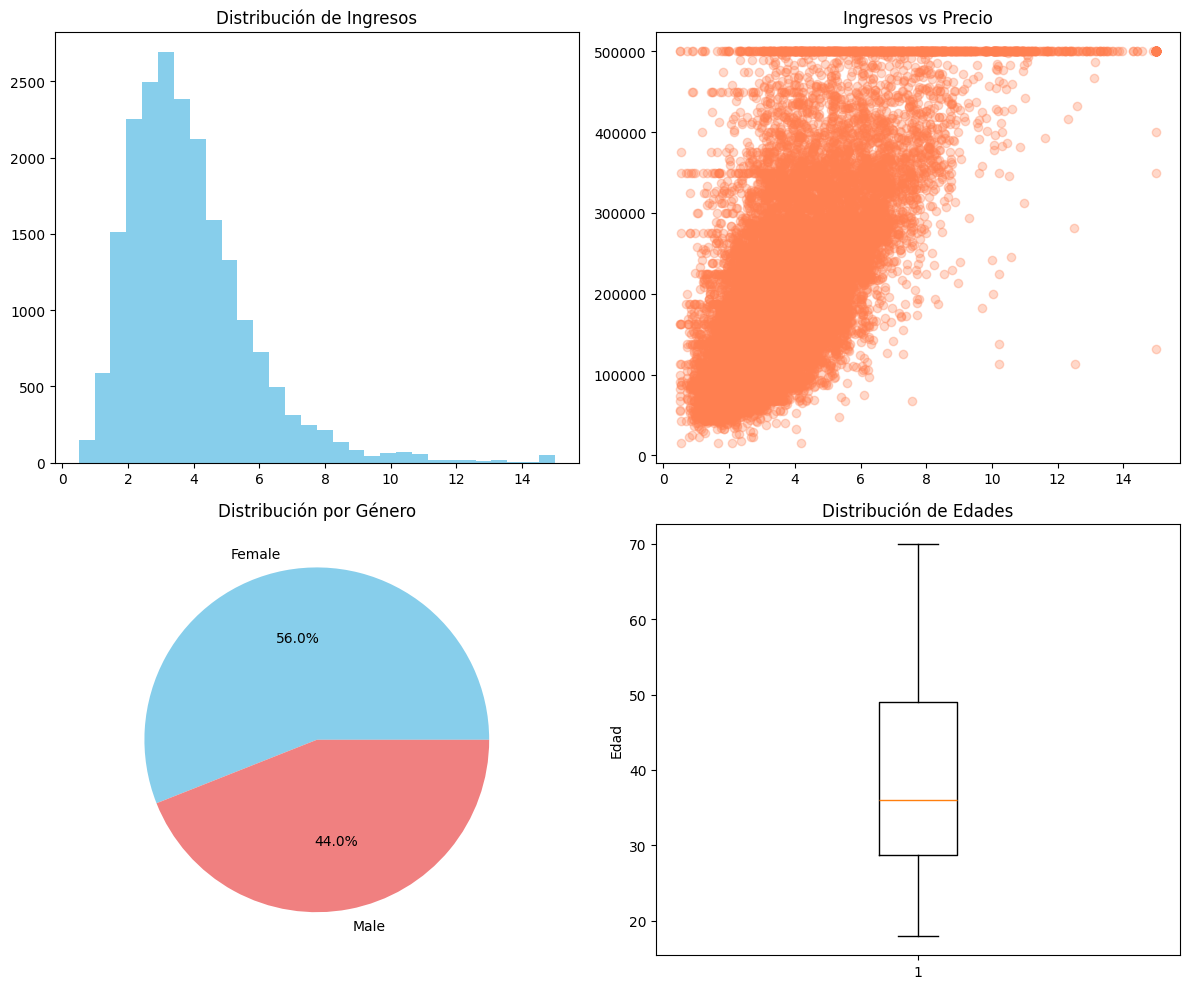

💡 Con subplots 2x2, accedemos a cada gráfico con axes[fila, columna]


In [52]:
# Subplots 2x2 (cuatro gráficos en cuadrícula)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Superior izquierda [0, 0]
axes[0, 0].hist(housing_df['median_income'], bins=30, color='skyblue')
axes[0, 0].set_title('Distribución de Ingresos')

# Superior derecha [0, 1]
axes[0, 1].scatter(housing_df['median_income'], housing_df['median_house_value'], alpha=0.3, color='coral')
axes[0, 1].set_title('Ingresos vs Precio')

# Inferior izquierda [1, 0]
gender_counts = mall_df['Gender'].value_counts()
axes[1, 0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
axes[1, 0].set_title('Distribución por Género')

# Inferior derecha [1, 1]
axes[1, 1].boxplot(mall_df['Age'].dropna())
axes[1, 1].set_title('Distribución de Edades')
axes[1, 1].set_ylabel('Edad')

plt.tight_layout()
plt.show()

print("💡 Con subplots 2x2, accedemos a cada gráfico con axes[fila, columna]")

C:\Users\bzarco\AppData\Local\Temp\ipykernel_20408\3316448157.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mall_df, x='Gender', y='Age', ax=axes[0, 1], palette='Set2')
C:\Users\bzarco\AppData\Local\Temp\ipykernel_20408\3316448157.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mall_df, x='Gender', ax=axes[1, 1], palette='pastel')


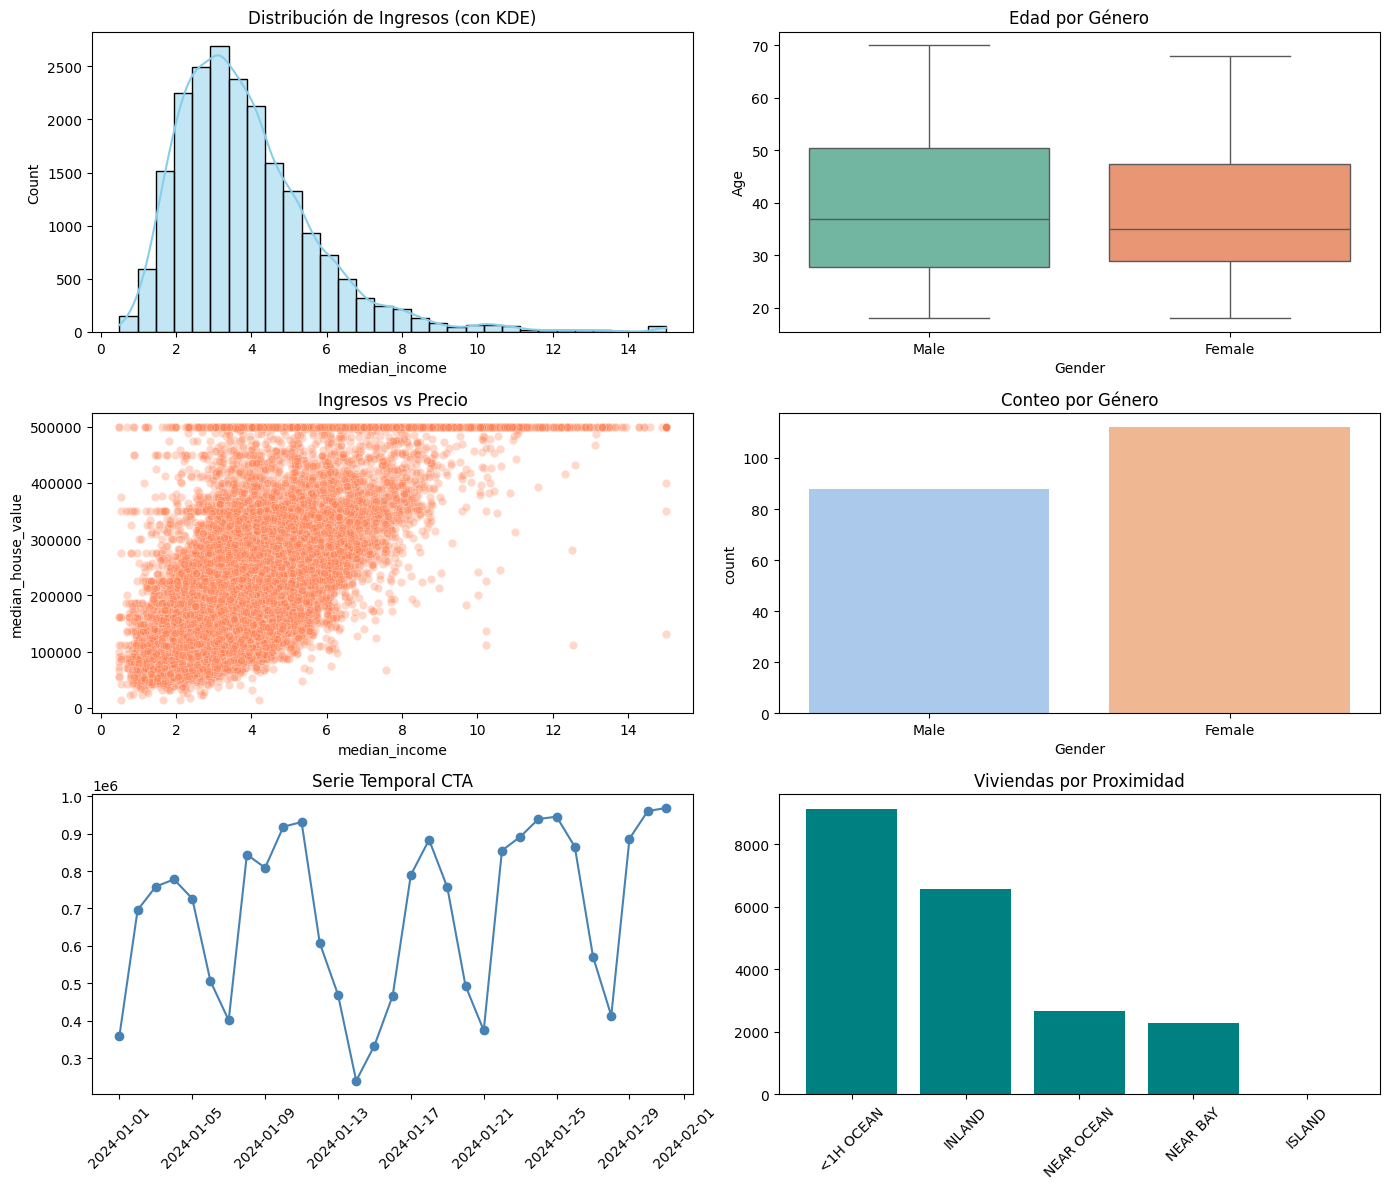

💡 Puedes mezclar gráficos de Matplotlib y Seaborn en los mismos subplots usando el parámetro ax=


In [53]:
# Subplots 3x2 combinando Seaborn y Matplotlib
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Fila 1
sns.histplot(housing_df['median_income'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de Ingresos (con KDE)')

sns.boxplot(data=mall_df, x='Gender', y='Age', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Edad por Género')

# Fila 2
sns.scatterplot(data=housing_df, x='median_income', y='median_house_value', alpha=0.3, ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Ingresos vs Precio')

sns.countplot(data=mall_df, x='Gender', ax=axes[1, 1], palette='pastel')
axes[1, 1].set_title('Conteo por Género')

# Fila 3
axes[2, 0].plot(cta_january_2024['service_date'], cta_january_2024['total_rides'], marker='o', color='steelblue')
axes[2, 0].set_title('Serie Temporal CTA')
axes[2, 0].tick_params(axis='x', rotation=45)

counts = housing_df['ocean_proximity'].value_counts()
axes[2, 1].bar(counts.index, counts.values, color='teal')
axes[2, 1].set_title('Viviendas por Proximidad')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("💡 Puedes mezclar gráficos de Matplotlib y Seaborn en los mismos subplots usando el parámetro ax=")

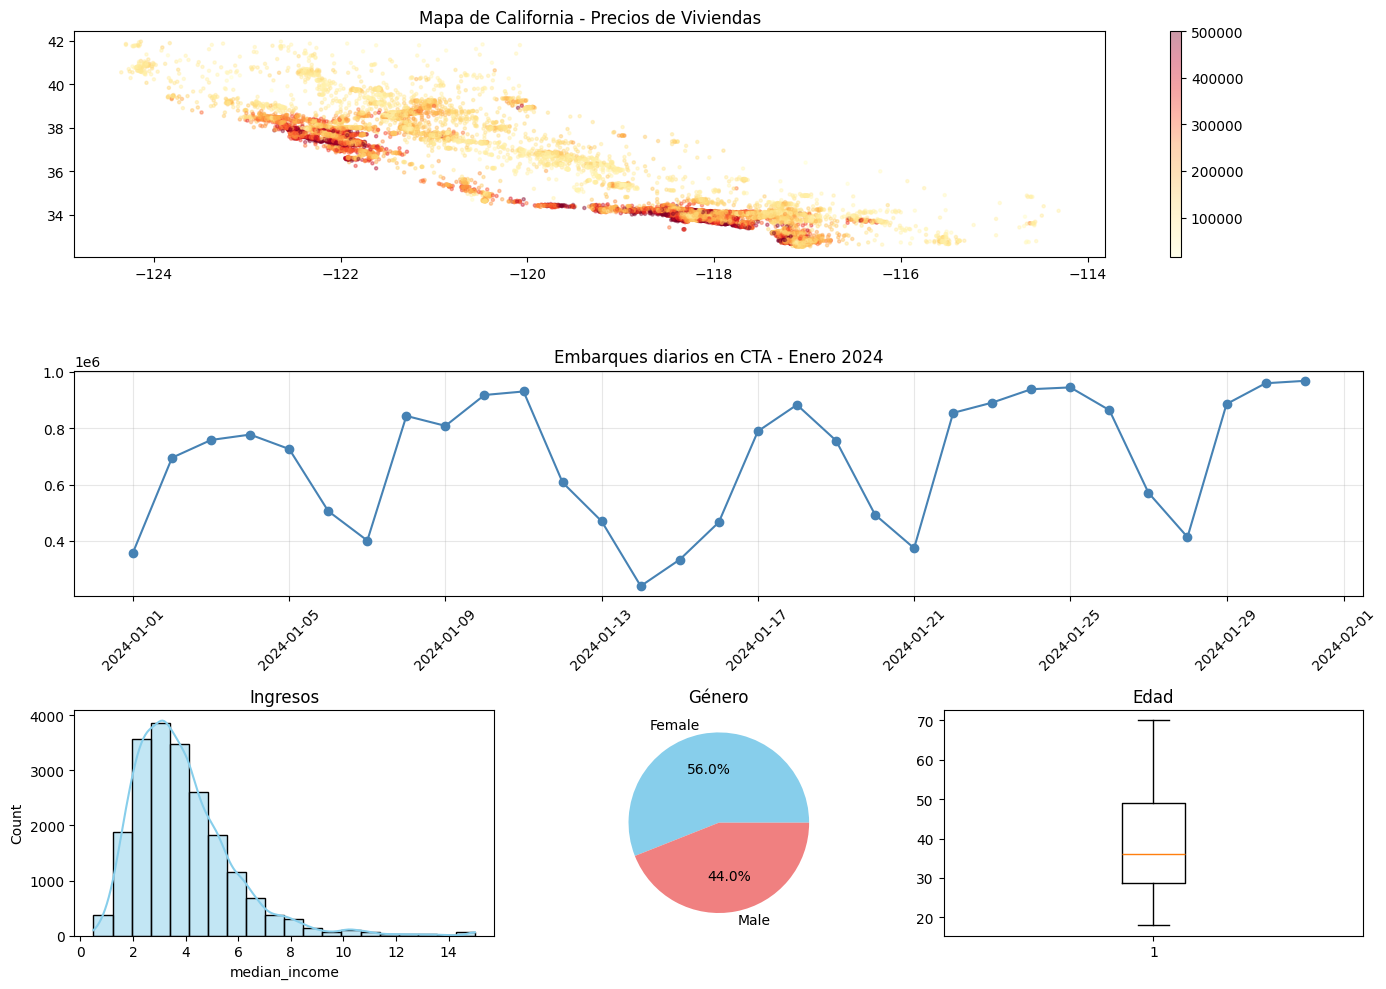

💡 GridSpec permite crear layouts complejos donde algunos gráficos ocupan múltiples filas/columnas


In [54]:
# Layout complejo con GridSpec (control avanzado de diseño)
from matplotlib import gridspec

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Gráfico grande arriba (ocupa toda la primera fila)
ax1 = fig.add_subplot(gs[0, :])
scatter = ax1.scatter(housing_df['longitude'], housing_df['latitude'], 
                      c=housing_df['median_house_value'], 
                      cmap='YlOrRd', alpha=0.4, s=5)
ax1.set_title('Mapa de California - Precios de Viviendas')
plt.colorbar(scatter, ax=ax1)

# Gráfico medio izquierdo (ocupa segunda fila completa)
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(cta_january_2024['service_date'], cta_january_2024['total_rides'], 
         marker='o', linestyle='-', color='steelblue')
ax2.set_title('Embarques diarios en CTA - Enero 2024')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Tres gráficos pequeños abajo
ax3 = fig.add_subplot(gs[2, 0])
sns.histplot(housing_df['median_income'], bins=20, kde=True, ax=ax3, color='skyblue')
ax3.set_title('Ingresos')

ax4 = fig.add_subplot(gs[2, 1])
gender_counts = mall_df['Gender'].value_counts()
ax4.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
        colors=['skyblue', 'lightcoral'])
ax4.set_title('Género')

ax5 = fig.add_subplot(gs[2, 2])
ax5.boxplot(mall_df['Age'].dropna())
ax5.set_title('Edad')

plt.tight_layout()
plt.show()

print("💡 GridSpec permite crear layouts complejos donde algunos gráficos ocupan múltiples filas/columnas")

# 🎓 Conclusiones

## 📚 Resumen de lo aprendido

En este cuaderno hemos explorado las dos librerías principales de visualización en Python:

**Matplotlib:**
- Control total sobre cada aspecto del gráfico
- Requiere más código pero ofrece máxima flexibilidad
- Ideal para gráficos personalizados y complejos
- Base para otras librerías de visualización

**Seaborn:**
- Gráficos estéticos con menos código
- Integración directa con pandas DataFrames
- Paletas de colores profesionales predefinidas
- Perfecto para análisis exploratorio de datos

**Subplots:**
- `plt.subplots(rows, cols)` crea grillas de gráficos
- Permite comparaciones visuales directas
- GridSpec ofrece layouts avanzados y complejos

## 🚀 Próximos pasos

- **Plotly**: Gráficos interactivos para dashboards web
- **Bokeh**: Visualizaciones interactivas de alto rendimiento
- **Altair**: Visualización declarativa basada en Vega-Lite
- **Dash**: Framework para crear aplicaciones de visualización

**Recursos útiles:**
- Matplotlib Gallery: https://matplotlib.org/stable/gallery/index.html
- Seaborn Examples: https://seaborn.pydata.org/examples/index.html
- Python Graph Gallery: https://python-graph-gallery.com/